# EDA 13: SAIPE vs. ACS for the same variable, Mercer County

**Question.** Q3 asks which public uncertainty metrics are fit for which uses. This notebook answers it with a direct comparison instead of an argument: the same variable, median household income, published by two different Census Bureau programs, each with its own uncertainty style.

**Plain-English setup.** ACS 5-year estimates come from a *sample* of households. The margin of error (MOE) on an ACS number is sampling error: how much the estimate would bounce around if we drew a different sample of the same size. SAIPE (Small Area Income and Poverty Estimates) is a different product entirely. It does not survey anyone new; it combines ACS data with tax and program records in a statistical model to produce a single county-level number, plus a published 90% confidence interval. That interval is model error: the sampling variance of its inputs, plus uncertainty about whether the model itself is right. See [`docs/glossary.md`](../docs/glossary.md) for both terms.

**Why this matters.** Both numbers ship as "estimate plus a range," and a county planner has no reason to assume the two ranges answer the same question. This notebook makes the distinction concrete with one pilot case, Mercer County (Trenton's county, the subject of the rest of this project), and checks a mechanical claim SAIPE makes about its own numbers: that the published margin of error equals `(upper bound - lower bound) / 2`.

**Data.** `data/raw/saipe_counties_2019_2024.parquet` (`ingestion/pull_saipe_counties.py`, all US counties, 2019-2024) and `data/raw/acs5_2024_trenton_county.parquet` (`ingestion/pull_trenton_dashboard.py`, Mercer County, ACS 5-year 2020-2024).

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Notebook lives in /notebooks; the analysis package lives at the repo root.
REPO_ROOT = Path.cwd() if (Path.cwd() / "analysis").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from analysis import common

SAIPE_PATH = REPO_ROOT / "data" / "raw" / "saipe_counties_2019_2024.parquet"
ACS_PATH = REPO_ROOT / "data" / "raw" / "acs5_2024_trenton_county.parquet"
YEAR = common.ACS_VINTAGE  # 2024 -- the year both products are compared at

for path, script in [
    (SAIPE_PATH, "python ingestion/pull_saipe_counties.py"),
    (ACS_PATH, "python ingestion/pull_trenton_dashboard.py"),
]:
    if not path.exists():
        raise FileNotFoundError(f"{path.relative_to(REPO_ROOT)} not found -- regenerate with: {script}")

saipe = pd.read_parquet(SAIPE_PATH)
mercer_saipe = saipe[
    (saipe["STATE"] == common.STATE_NJ) & (saipe["NAME"] == "Mercer County") & (saipe["year"] == YEAR)
].iloc[0]

mercer_acs = pd.read_parquet(ACS_PATH).iloc[0]

print(f"Mercer County, NJ -- median household income, {YEAR}\n")
print(f"  ACS 5-year (sampling error):  {mercer_acs['B19013_001E']:>10,.0f}"
      f"   +/- {mercer_acs['B19013_001M']:,.0f}  (90% MOE)")
print(f"  SAIPE (model error):          {mercer_saipe['SAEMHI_PT']:>10,.0f}"
      f"   90% CI [{mercer_saipe['SAEMHI_LB90']:,.0f} - {mercer_saipe['SAEMHI_UB90']:,.0f}]"
      f"   (published MOE {mercer_saipe['SAEMHI_MOE']:,.0f})")

Mercer County, NJ -- median household income, 2024

  ACS 5-year (sampling error):     100,645   +/- 2,565  (90% MOE)
  SAIPE (model error):             102,760   90% CI [98,661 - 106,859]   (published MOE 4,099)


## 1. Check SAIPE's own claim about its interval

SAIPE publishes three things for the same quantity: a point estimate, a 90% confidence interval (`LB90`/`UB90`), and a margin of error (`MOE`). If the interval is genuinely symmetric at 90% confidence, `MOE` should equal `(UB90 - LB90) / 2` exactly. `analysis.common.half_width` computes that derived value; the ingestion script already checked this across all ~18,900 county-year rows when it pulled the data (`ingestion/pull_saipe_counties.py::sanity_report`). This cell repeats the check here, on Mercer specifically and on the full national file, so the notebook is self-contained and does not just take the pull script's word for it.

In [2]:
derived_mercer = common.half_width(mercer_saipe["SAEMHI_LB90"], mercer_saipe["SAEMHI_UB90"])
assert abs(derived_mercer - mercer_saipe["SAEMHI_MOE"]) < 1.0, (
    f"Mercer: derived half-width {derived_mercer:,.1f} vs published MOE "
    f"{mercer_saipe['SAEMHI_MOE']:,.1f} -- expected agreement within $1"
)
print(f"Mercer: (UB90-LB90)/2 = {derived_mercer:,.1f}  vs published MOE = "
      f"{mercer_saipe['SAEMHI_MOE']:,.1f}  -- match")

# Same check nationwide, all years, both variables -- not just the pilot case.
for pt, lb, ub, moe in [
    ("SAEMHI_PT", "SAEMHI_LB90", "SAEMHI_UB90", "SAEMHI_MOE"),
    ("SAEPOVRTALL_PT", "SAEPOVRTALL_LB90", "SAEPOVRTALL_UB90", "SAEPOVRTALL_MOE"),
]:
    derived = common.half_width(saipe[lb], saipe[ub])
    comparable = derived.notna() & saipe[moe].notna()
    diff = (derived[comparable] - saipe[moe][comparable]).abs()
    agree = int((diff <= 1).sum())
    total = int(comparable.sum())
    assert agree == total, f"{moe}: only {agree}/{total} rows agree with the derived half-width within $1"
    print(f"{moe}: {agree:,}/{total:,} county-years agree within 1 unit "
          f"(max abs diff {diff.max():.3f})")

Mercer: (UB90-LB90)/2 = 4,099.0  vs published MOE = 4,099.0  -- match
SAEMHI_MOE: 18,854/18,854 county-years agree within 1 unit (max abs diff 0.000)
SAEPOVRTALL_MOE: 18,854/18,854 county-years agree within 1 unit (max abs diff 0.000)


## 2. The two ranges, side by side

Both intervals check out on their own terms: SAIPE's published MOE agrees exactly with its own bounds, and ACS's MOE is the Bureau's standard sampling-error product. The point this notebook exists to make is what happens next, when someone puts both ranges in front of a county planner.

A wider SAIPE interval does not mean SAIPE is "less precise" than ACS, and a narrower one does not mean it is "more precise." The two intervals are answers to different questions:

- ACS asks: if we surveyed a different sample of Mercer County households, how much would this estimate move?
- SAIPE asks: given everything the model uses (ACS data, tax records, population estimates), how much uncertainty is there about the true value, including the possibility that the model's assumptions are wrong?

Comparing the widths at face value treats "model error" and "sampling error" as the same currency. They are not, and nothing in either publication converts one into the other.

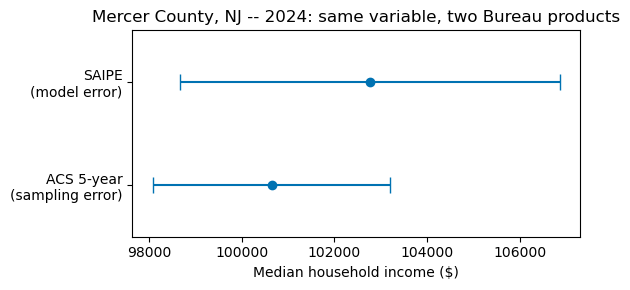


ACS width:   $5,130   (sampling error only)
SAIPE width: $8,198   (sampling error + model uncertainty)


In [3]:
import matplotlib.pyplot as plt

acs_est, acs_moe = mercer_acs["B19013_001E"], mercer_acs["B19013_001M"]
saipe_est, saipe_lo, saipe_hi = (
    mercer_saipe["SAEMHI_PT"], mercer_saipe["SAEMHI_LB90"], mercer_saipe["SAEMHI_UB90"]
)

fig, ax = plt.subplots(figsize=(6, 3))
rows = [
    ("ACS 5-year\n(sampling error)", acs_est, acs_est - acs_moe, acs_est + acs_moe),
    ("SAIPE\n(model error)", saipe_est, saipe_lo, saipe_hi),
]
for i, (label, est, lo, hi) in enumerate(rows):
    ax.errorbar(est, i, xerr=[[est - lo], [hi - est]], fmt="o", capsize=6, color="#0072B2")
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([r[0] for r in rows])
ax.set_xlabel("Median household income ($)")
ax.set_title(f"Mercer County, NJ -- {YEAR}: same variable, two Bureau products")
ax.set_ylim(-0.5, len(rows) - 0.5)
fig.tight_layout()
plt.show()

print(f"\nACS width:   ${2 * acs_moe:,.0f}   (sampling error only)")
print(f"SAIPE width: ${saipe_hi - saipe_lo:,.0f}   (sampling error + model uncertainty)")

## Findings

**What we found.** For Mercer County, 2024, ACS reports median household income $100,645 +/- $2,565 (sampling error). SAIPE reports $102,760, 90% CI [$98,661 - $106,859] (model error), a wider interval on a similar point estimate. SAIPE's published MOE matches its own `(UB90-LB90)/2` exactly, on Mercer and on every one of the ~18,900 county-year rows pulled, both variables. Both products are internally consistent; they are just not measuring the same kind of uncertainty.

**Why it matters to the Census Bureau.** A county planner handed both numbers with no explanation would reasonably assume the wider one is "less reliable." That is not what a wider SAIPE interval means, and the Bureau's own documentation does not currently walk a non-technical reader through the distinction at the point where the numbers are published side by side. This is the strongest direct evidence in this project for Q3: the same variable, from the same agency, needs different communication depending on which product is producing it.

**What's next.** SAIPE stops at the county level, so this comparison cannot extend to the tract view that carries the rest of the app's story. The Streamlit app surfaces one comparison element at the Mercer County geography level only (`Streamlit/app.py`), pointing back to this notebook rather than duplicating the chart. PUMS and replicate-weight-based uncertainty remain a confirmed-but-unbuilt product (README "Candidate Datasets"), outside this notebook's scope.